In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_dilated_convolutions_no_proteins import CNNModel
from networks.cnn_dilated_convolutions_no_proteins import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

train_rows = df[df['set'] == 'train']
val_rows = df[df['set'] == 'val']
test_rows = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
CNN.reset_weights()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)


Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_proteins.pth
Epoch   0 | train: 0.6805 | val: 0.5609 | acc: 92.74% | AUC: 0.826  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_proteins.pth
Epoch   1 | train: 0.5072 | val: 0.3549 | acc: 94.41% | AUC: 0.903  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_proteins.pth
Epoch   2 | train: 0.3916 | val: 0.2427 | acc: 96.72% | AUC: 0.944  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_proteins.pth
Epoch   3 | train: 0.3096 | val: 0.2957 | acc: 90.43% | AUC: 0.977  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_proteins.pth
Epoch   4 | train: 0.2500 | val: 0.1408 | acc: 97.63% | AUC: 0.985  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_p

In [2]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows)

Totalt antal utan m-komponent i K-fold poolen: 18848
Totalt antal med m-komponent i K-fold poolen: 2692
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_proteins_fold1.pth
Epoch   0 | train: 0.6777 | val: 0.6133 | acc: 88.16% | AUC: 0.781  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_proteins_fold1.pth
Epoch   1 | train: 0.4992 | val: 0.4722 | acc: 91.46% | AUC: 0.862  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_proteins_fold1.pth
Epoch   2 | train: 0.3674 | val: 0.3526 | acc: 94.01% | AUC: 0.937  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_proteins_fold1.pth
Epoch   3 | train: 0.2566 | val: 0.2620 | acc: 93.13% | AUC: 0.962  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_no_proteins_fold1.pth
Epoch   4 | train: 0.2080 | val: 0.2031 | acc: 95.08% | AU

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.133341,0.181117,93.593315,0.988519,0.930467,0.974074,1753,131,7,263
1,2,0.084589,0.099332,96.193129,0.993929,0.960191,0.974074,1809,75,7,263
2,3,0.063344,0.127281,96.053853,0.989063,0.966048,0.921933,1821,64,21,248
3,4,0.059309,0.126387,97.260910,0.990173,0.975066,0.955390,1838,47,12,257
4,5,0.105133,0.136983,93.361188,0.992214,0.927851,0.973978,1749,136,7,262
5,6,0.055180,0.080558,97.353760,0.995409,0.976658,0.951673,1841,44,13,256
6,7,0.093441,0.125631,95.636026,0.988402,0.956499,0.955390,1803,82,12,257
7,8,0.086792,0.156542,96.239554,0.986201,0.969761,0.910781,1828,57,24,245
8,9,0.053854,0.167040,96.285980,0.989731,0.966578,0.936803,1822,63,17,252
9,10,0.062483,0.095551,95.728877,0.992825,0.958090,0.951673,1806,79,13,256


              precision    recall  f1-score   support

     Negativ       1.00      0.97      0.98      7056
     Positiv       0.54      0.97      0.70       250

    accuracy                           0.97      7306
   macro avg       0.77      0.97      0.84      7306
weighted avg       0.98      0.97      0.97      7306

[[6853  203]
 [   8  242]]


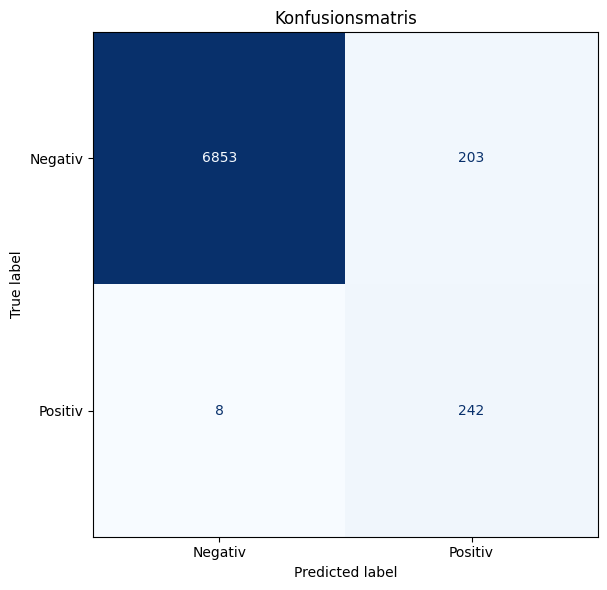

AUC: 0.992
Accuracy:  97.11%
FN-rate:   3.20%  (farliga missade fall)
FP-rate:   2.88%  (onödiga larm)
Sensitivitet:   96.80%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   97.12%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9920


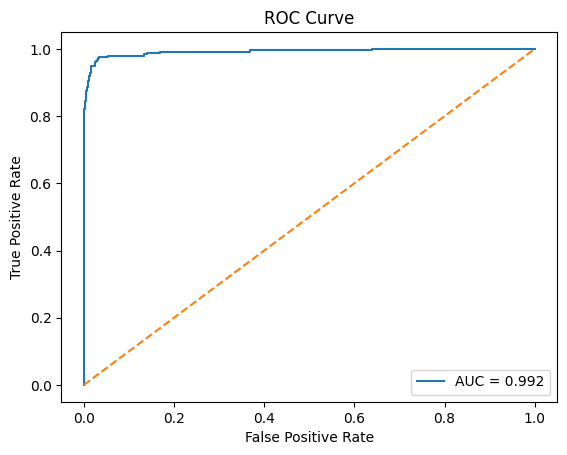

In [3]:
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = CNN.predict(test_rows)
_ = evaluate(result)